# Pure-Component Cubic EOS — Milestone 7 (v0.3.0)

Every multicomponent flash, every bubble-point search, every distillation column simulation eventually decomposes into **pure-component questions**: at this T and P, what is the compressibility factor of n-pentane? What is its fugacity coefficient? How does its saturation pressure scale with temperature? Milestone 7.1 ships the deployable core that answers those questions — the four most-used cubic equations of state (Peng-Robinson, RKS, original RK, van der Waals), the Antoine vapor-pressure correlation, and the truncated virial equation.

## Setup (optional)

The cell below is **commented out by default**. Uncomment it if you want to use the latest `vle-thermo` released on PyPI instead of whatever version is currently installed in your kernel.

In [1]:
# Optional: pull the latest vle-thermo from PyPI.
# Uncomment if you want the newest released version instead of
# whatever is currently in your kernel.
# %pip install --upgrade vle-thermo

## Context — Chapter II §2.3 (cubic EOS) in code form

From [Chapter II §2.3](https://github.com/miguelju/vle/blob/main/docs/en/research-paper/chapter-2-vle-theory.md): every cubic equation of state in this library shares the **Abbott form**

$$P = \frac{R T}{V - b} - \frac{a \, \alpha(T)}{V^2 + k_1 b V + k_2 b^2}$$

where `a = Ω_a · R² T_c² / P_c`, `b = Ω_b · R T_c / P_c`, and `α(T)` is the variant-specific temperature dependence. The four core variants in this notebook differ only in those `(k_1, k_2, Ω_a, Ω_b, α)` choices:

| EOS | `k_1` | `k_2` | `Ω_a` | `Ω_b` | α(T_r) |
|---|---|---|---|---|---|
| van der Waals (1870) | 0 | 0 | 27/64 | 1/8 | 1 |
| Redlich-Kwong (1949) | 1 | 0 | 0.427480 | 0.086640 | T_r^(-1/2) |
| Soave-RK (1972) | 1 | 0 | 0.427480 | 0.086640 | [1 + m(1 − √T_r)]², m = 0.48 + 1.574ω − 0.176ω² |
| Peng-Robinson (1976) | 2 | -1 | 0.457236 | 0.077796 | [1 + κ(1 − √T_r)]², κ = 0.37464 + 1.54226ω − 0.26992ω² |

Those four sets of constants live verbatim in [`engine/src/eos.rs`](https://github.com/miguelju/vle/blob/main/engine/src/eos.rs) (family_constants table from `legacy/vb6/McommonFunctions.bas:273`). The other 12 two-parameter α variants from VB6 (PRSV, polar Mathias-Naumann extensions, etc.) shipped in **M7.2** — see [`02b_alpha_zoo.ipynb`](02b_alpha_zoo.ipynb). The three OL-family variants (M7.4) and the three-parameter Pascal EOS (Schmidt-Wenzel, Patel-Teja; M7.3) are still to come — see [`02c_three_param_eos.ipynb`](02c_three_param_eos.ipynb).

## What was built in Milestone 7.1

Ten public PyO3-bound functions, every one with an analytical derivative where one exists:

Cubic EOS (`engine/src/eos.rs`):
- `eos_family_constants(eos)` — returns `(k_1, k_2, Ω_a, Ω_b)`
- `eos_alpha(eos, T_r, ω)` and `eos_d_alpha_d_tr(eos, T_r, ω)`
- `eos_z_factor(eos, T, P, T_c, P_c, ω, phase)` — solves the cubic in Z and picks the liquid or vapor root
- `eos_ln_phi_pure(...)` — pure-component fugacity coefficient ln φ
- `eos_h_departure_rt(...)` — H^R/(RT), dimensionless
- `eos_s_departure_r(...)` — S^R/R, dimensionless

Saturation (`engine/src/saturation.rs`):
- `antoine_psat(T, P_c, coeffs)` — Da Silva form ln(P/Pc) = a₁ − a₂/(a₃+T)
- `antoine_d_psat_dt(...)` — analytical dP_sat/dT

Virial (`engine/src/virial.rs`):
- `virial_pitzer_b0(T_r)`, `virial_pitzer_b1(T_r)` — Pitzer correlation
- `virial_b_pure(...)`, `virial_d_b_d_t_pure(...)`
- `virial_z(...)`, `virial_ln_phi(...)`
- `virial_h_dep_rt(...)`, `virial_s_dep_r(...)`
- `virial_b_mix_py(...)`, `virial_ln_phi_mix(...)` — mixture (M7.6)

In [2]:
import math

import matplotlib.pyplot as plt
import numpy as np

from vle._engine import (
    CubicEos,
    antoine_d_psat_dt,
    antoine_psat,
    eos_alpha,
    eos_d_alpha_d_tr,
    eos_family_constants,
    eos_h_departure_rt,
    eos_ln_phi_pure,
    eos_z_factor,
    version,
    virial_b_mix_py,
    virial_b_pure,
    virial_ln_phi,
    virial_ln_phi_mix,
    virial_pitzer_b0,
    virial_pitzer_b1,
    virial_z,
)

print(f'vle._engine version: {version()}')

vle._engine version: 0.4.0


### Component data

Two reference components used throughout — methane (a small, near-spherical molecule with a tiny acentric factor) and n-pentane (an everyday hydrocarbon where ω = 0.252 actually matters). Numbers from NIST.

In [3]:
METHANE = dict(name='methane', Tc=190.564, Pc=4599.0, omega=0.0115)
N_PENTANE = dict(name='n-pentane', Tc=469.7, Pc=3370.0, omega=0.252)

for c in (METHANE, N_PENTANE):
    print(f"{c['name']:>10s}: Tc={c['Tc']:.2f} K, Pc={c['Pc']:.0f} kPa, ω={c['omega']:.4f}")

   methane: Tc=190.56 K, Pc=4599 kPa, ω=0.0115
 n-pentane: Tc=469.70 K, Pc=3370 kPa, ω=0.2520


## 1. α(T_r) across the four core EOS for n-pentane

Plot α as a function of reduced temperature for each variant. All four collapse to α=1 at the critical point (T_r=1); below T_c the curves diverge — RK falls off as T_r^(−1/2), while PR and RKS have the cleanest matched behavior near T_r=1.

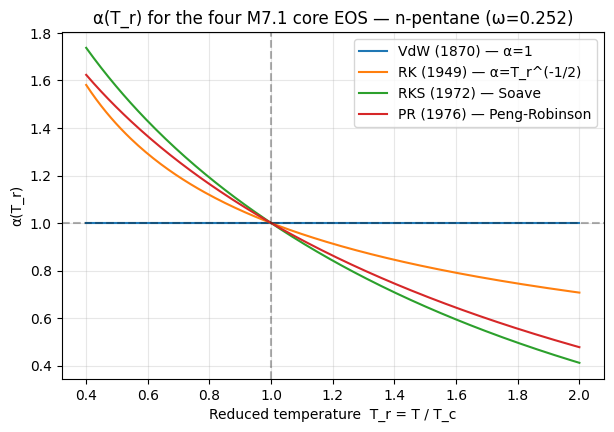

In [4]:
trs = np.linspace(0.4, 2.0, 200)
fig, ax = plt.subplots(figsize=(7, 4.5))

for eos, label in [
    (CubicEos.VdW1870,  'VdW (1870) — α=1'),
    (CubicEos.RK1949,   'RK (1949) — α=T_r^(-1/2)'),
    (CubicEos.RKS1972,  'RKS (1972) — Soave'),
    (CubicEos.PR1976,   'PR (1976) — Peng-Robinson'),
]:
    alphas = [eos_alpha(eos, float(tr), N_PENTANE['omega']) for tr in trs]
    ax.plot(trs, alphas, label=label)

ax.axvline(1.0, color='k', alpha=0.3, linestyle='--')
ax.axhline(1.0, color='k', alpha=0.3, linestyle='--')
ax.set_xlabel('Reduced temperature  T_r = T / T_c')
ax.set_ylabel('α(T_r)')
ax.set_title('α(T_r) for the four M7.1 core EOS — n-pentane (ω=0.252)')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## 2. PR Z-factor isotherms for methane

At supercritical T (300 K, T_r ≈ 1.57) the cubic in Z has one real root: Z is single-valued from low to high P. At near-critical T (180 K, T_r ≈ 0.94) the cubic has three real roots in a P window — the liquid Z (lowest), an unstable middle root, and the vapor Z. The isotherm splits at the saturation envelope.

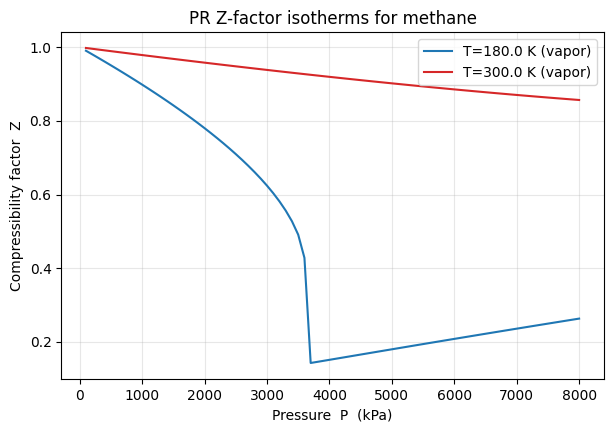

In [5]:
ps = np.linspace(100.0, 8000.0, 80)
fig, ax = plt.subplots(figsize=(7, 4.5))

for T, color in [(180.0, 'tab:blue'), (300.0, 'tab:red')]:
    z_vap, z_liq = [], []
    for p in ps:
        try:
            z_vap.append((p, eos_z_factor(CubicEos.PR1976, T, float(p),
                                          METHANE['Tc'], METHANE['Pc'], METHANE['omega'], 'vapor')))
        except RuntimeError:
            pass
        try:
            z_liq.append((p, eos_z_factor(CubicEos.PR1976, T, float(p),
                                          METHANE['Tc'], METHANE['Pc'], METHANE['omega'], 'liquid')))
        except RuntimeError:
            pass
    if z_vap:
        xs, ys = zip(*z_vap)
        ax.plot(xs, ys, color=color, label=f'T={T} K (vapor)')
    if z_liq:
        xs, ys = zip(*z_liq)
        # Only plot liquid branch where it differs from vapor (sub-critical).
        xs, ys = list(xs), list(ys)
        if max(ys) < 0.3:
            ax.plot(xs, ys, '--', color=color, label=f'T={T} K (liquid)')

ax.set_xlabel('Pressure  P  (kPa)')
ax.set_ylabel('Compressibility factor  Z')
ax.set_title('PR Z-factor isotherms for methane')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## 3. Antoine vapor pressure and its derivative

The Antoine form in this library uses the Da Silva (1989) convention `ln(P_sat / P_c) = a_1 − a_2 / (a_3 + T)`, so the coefficients are tabulated against `P_c` not against 1 atm. The analytical `dP_sat/dT = P_sat · a_2 / (a_3 + T)²` matches central differences to floating-point precision.

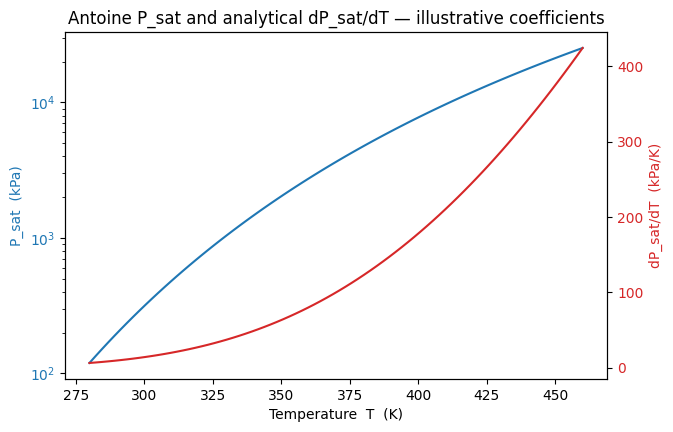

In [6]:
# Plausible coefficients for an n-pentane-like compound (illustration).
Pc = N_PENTANE['Pc']
coeffs = [9.0, 2900.0, -45.0]

Ts = np.linspace(280.0, 460.0, 80)
psats = [antoine_psat(float(T), Pc, coeffs) for T in Ts]

fig, ax1 = plt.subplots(figsize=(7, 4.5))
ax1.plot(Ts, psats, 'tab:blue', label='P_sat')
ax1.set_xlabel('Temperature  T  (K)')
ax1.set_ylabel('P_sat  (kPa)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_yscale('log')

ax2 = ax1.twinx()
d_an = [antoine_d_psat_dt(float(T), Pc, coeffs) for T in Ts]
ax2.plot(Ts, d_an, 'tab:red', label='dP_sat/dT (analytical)')
ax2.set_ylabel('dP_sat/dT  (kPa/K)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Antoine P_sat and analytical dP_sat/dT — illustrative coefficients')
plt.show()

## 4. Truncated virial — B(T) and the ideal-gas crossover

Pitzer's correlation gives the second virial coefficient as `B · P_c / (R · T_c) = B⁰(T_r) + ω · B¹(T_r)` with

$$B^0 = 0.083 - 0.422 / T_r^{1.6}, \quad B^1 = 0.139 - 0.172 / T_r^{4.2}$$

B(T) is negative at low T (attractive forces dominate, Z < 1) and crosses zero around T_r ≈ 2.7 for most fluids — the Boyle temperature, where the truncated virial reduces exactly to the ideal-gas law.

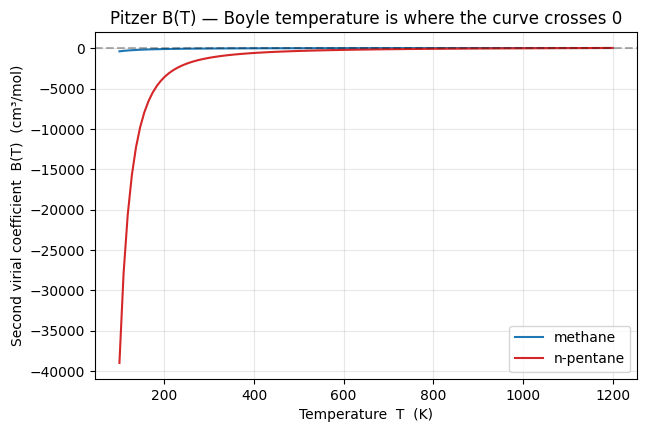

In [7]:
Ts = np.linspace(100.0, 1200.0, 120)
fig, ax = plt.subplots(figsize=(7, 4.5))

for c, color in [(METHANE, 'tab:blue'), (N_PENTANE, 'tab:red')]:
    Bs = [virial_b_pure(c['Tc'], c['Pc'], c['omega'], float(T)) for T in Ts]
    ax.plot(Ts, Bs, color=color, label=c['name'])

ax.axhline(0.0, color='k', alpha=0.3, linestyle='--')
ax.set_xlabel('Temperature  T  (K)')
ax.set_ylabel('Second virial coefficient  B(T)  (cm³/mol)')
ax.set_title('Pitzer B(T) — Boyle temperature is where the curve crosses 0')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## 5. Mixture virial — methane / n-pentane partial fugacity

For a 60% methane + 40% n-pentane mixture at 350 K, 1000 kPa, the truncated virial gives a partial fugacity coefficient for each component via

$$\ln \hat\varphi_i = \frac{P}{RT}\left(2\sum_j x_j B_{ij} - B_{\text{mix}}\right)$$

with Lewis-Randall quadratic mixing for B(T, x). The methane partial ln(φ) ends up slightly *positive* (the small molecule is squeezed by the long-chain neighbor); the pentane partial ln(φ) is more negative than its pure value.

In [8]:
tcs    = [METHANE['Tc'],    N_PENTANE['Tc']]
pcs    = [METHANE['Pc'],    N_PENTANE['Pc']]
omegas = [METHANE['omega'], N_PENTANE['omega']]
xs     = [0.6, 0.4]
T, P   = 350.0, 1000.0

b_mix = virial_b_mix_py(tcs, pcs, omegas, xs, T)
ln_phi_i = virial_ln_phi_mix(tcs, pcs, omegas, xs, T, P)
ln_phi_pure_methane = virial_ln_phi(*[METHANE[k] for k in ('Tc', 'Pc', 'omega')], T, P)
ln_phi_pure_pentane = virial_ln_phi(*[N_PENTANE[k] for k in ('Tc', 'Pc', 'omega')], T, P)

print(f'B_mix = {b_mix:.2f} cm³/mol')
print(f'ln(φ_methane,   pure)    = {ln_phi_pure_methane:+.4f}')
print(f'ln(φ_methane,   mixture) = {ln_phi_i[0]:+.4f}')
print(f'ln(φ_pentane,   pure)    = {ln_phi_pure_pentane:+.4f}')
print(f'ln(φ_pentane,   mixture) = {ln_phi_i[1]:+.4f}')

B_mix = -211.89 cm³/mol
ln(φ_methane,   pure)    = -0.0089
ln(φ_methane,   mixture) = +0.0212
ln(φ_pentane,   pure)    = -0.2814
ln(φ_pentane,   mixture) = -0.2138


## Exercises

Two exercises that exercise the bindings end-to-end. Solutions are in collapsible `<details>` blocks at the bottom.

### Exercise 1 — Compare PR and RKS for benzene at 350 K, 2000 kPa

Benzene has T_c = 562.05 K, P_c = 4895 kPa, ω = 0.212. Compute the **liquid** Z, **vapor** Z, and pure-component ln(φ) for both PR1976 and RKS1972 at this T, P. Which EOS predicts a denser liquid (smaller Z_liquid)?

In [9]:
# TODO: compute z_l, z_v, ln_phi_l, ln_phi_v for both EOS and print them.
# Hint: use the 'liquid' / 'vapor' phase strings; benzene is sub-critical at 350 K.
BENZENE = dict(Tc=562.05, Pc=4895.0, omega=0.212)
T, P = 350.0, 2000.0

# ...


<details>
<summary>Solution</summary>

```python
for eos, label in [(CubicEos.PR1976, 'PR'), (CubicEos.RKS1972, 'RKS')]:
    z_l = eos_z_factor(eos, T, P, **BENZENE, phase='liquid')
    z_v = eos_z_factor(eos, T, P, **BENZENE, phase='vapor')
    ln_phi_l = eos_ln_phi_pure(eos, T, P, **BENZENE, phase='liquid')
    ln_phi_v = eos_ln_phi_pure(eos, T, P, **BENZENE, phase='vapor')
    print(f'{label}: Z_l={z_l:.4f}, Z_v={z_v:.4f}, ln(φ_l)={ln_phi_l:+.4f}, ln(φ_v)={ln_phi_v:+.4f}')
```

PR predicts the smaller Z_liquid (denser liquid) — the classic PR vs RKS finding for sub-critical hydrocarbons.
</details>

### Exercise 2 — Find the Boyle temperature of methane

The Boyle temperature is the T at which B(T) = 0. Use the Brent root finder from M6 (`vle._engine.brent`) to find it for methane between 300 K and 1500 K.

In [10]:
from vle._engine import brent

# TODO: define a callable that returns virial_b_pure(...) for methane
# at a given T, and pass it to brent() with a bracket that straddles
# the Boyle temperature.

# ...


<details>
<summary>Solution</summary>

```python
def b_of_t(t):
    return virial_b_pure(METHANE['Tc'], METHANE['Pc'], METHANE['omega'], float(t))

t_boyle = brent(b_of_t, 300.0, 1500.0, 1e-6)
print(f'Methane Boyle temperature: T = {t_boyle:.2f} K  (T_r = {t_boyle / METHANE["Tc"]:.3f})')
```

Around T ≈ 510 K, i.e. T_r ≈ 2.7 — matches the universal value predicted by the Pitzer correlation.
</details>

## References

- **Research paper, Chapter II §2.3** — cubic EOS derivation and the Abbott family form. [`docs/en/research-paper/chapter-2-vle-theory.md`](https://github.com/miguelju/vle/blob/main/docs/en/research-paper/chapter-2-vle-theory.md)
- **MODERNIZATION_PLAN.md — Phase 7 / 8 / 9** — phase-level scope notes for the pure-component layer. [`MODERNIZATION_PLAN.md`](https://github.com/miguelju/vle/blob/main/docs/plans/MODERNIZATION_PLAN.md)
- **Reference (4): Da Silva & Báez (1989)** — Antoine form and 3-parameter EOS source. `legacy/pascal/TERMOI.PAS` (Antoine) and `TERMOII.PAS` (3-param EOS, deferred to M7.3).
- **Reference (5): Abbott (1989)** — cubic EOS family form. `legacy/vb6/McommonFunctions.bas:273` for the family-constants table.
- **Reference (12): Poling, Prausnitz, O'Connell (2001)** — the discriminant robustness for the cubic solver (used by the Z-factor code path).
- **Companion notebooks** (planned for later v0.x releases): [`02b_alpha_zoo.ipynb`](02b_alpha_zoo.ipynb) (M7.2, v0.4.0), [`02c_three_param_eos.ipynb`](02c_three_param_eos.ipynb) (M7.3, v0.5.0), and [`02d_advanced_saturation.ipynb`](02d_advanced_saturation.ipynb) (M7.4, v0.6.0).